# Impact of Zero Location on System Model

In [1]:
import requests as req, os
URL = "https://raw.githubusercontent.com/mit-acl/16_06_Class/main/"
File = ["basic_material.py","control_materials.py","read_csv_data.py"]
try:
    %run basic_material.py
    print('Basic file found')
except:    
    print('Basic files not` found - downloading it')
    for dfile in File:
        if not os.path.isfile(dfile):
            print(dfile)
            res = req.get(URL+dfile)
            file = open(dfile, 'w')
            file.write(res.text)
            file.close()
    %run basic_material.py

try:
    from control.matlab import tf,step, tf2ss, ss2tf, bode
except:
    !python3 -m pip install control
    from control.matlab import tf,step, tf2ss, ss2tf, bode

import scipy
from scipy.signal import residue

Running Python: 3.8.17
Running Sympy: 1.12rc1
Basic file found


# Adding Zeros

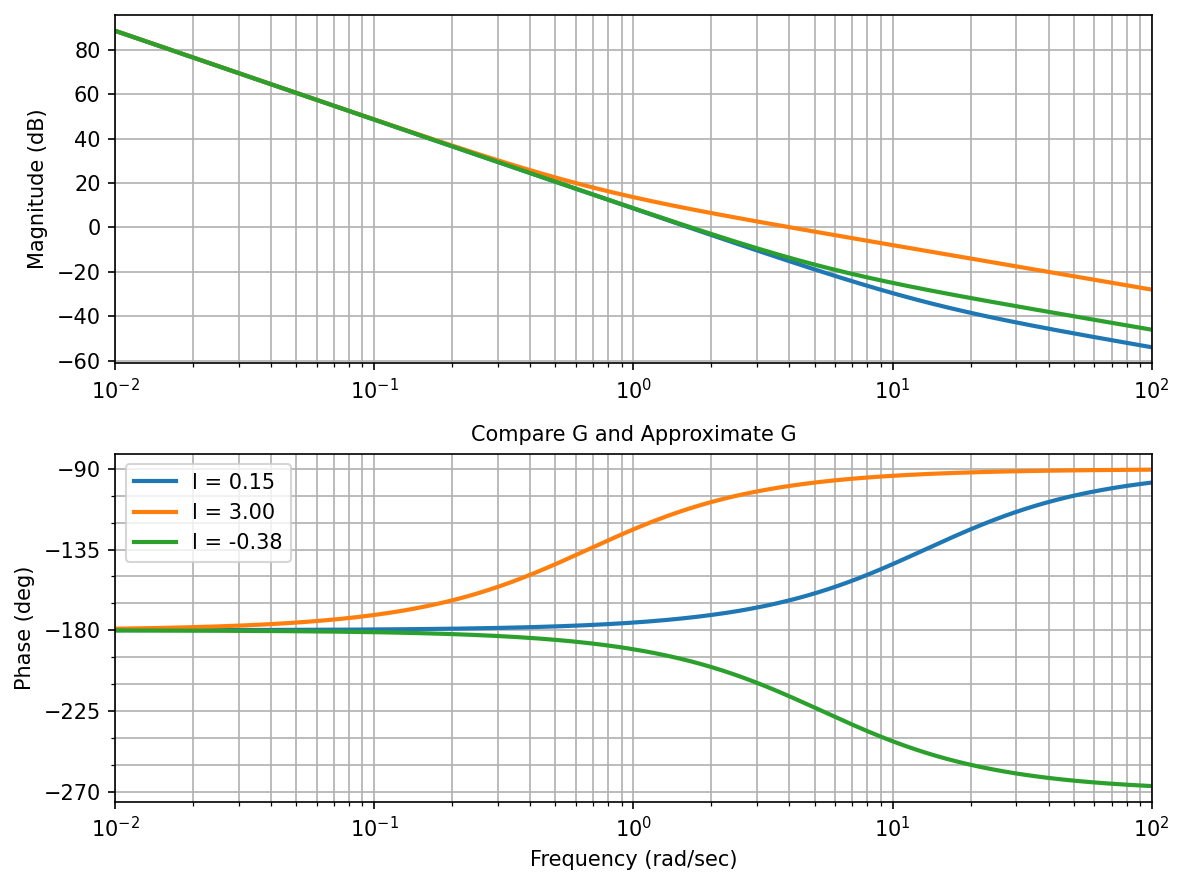

In [16]:
# Bicycle model of car
V0 = 2 # baseline speed
b = 1.5 # between axles
s = tf('s')

L = np.array([0.1*b, 2*b, -0.25*b])
P = {}
fig, ax = plt.subplots(2,1,figsize=(8, 6),dpi=150,sharex = True)

for l in L:
    P[l] = V0/b*(V0+l*s)/s**2
    gain, phase, w = bode(P[l], logspace(-2,2,500),label='l = {:3.2f}'.format(l))
    
ax[1].set_xlabel("Frequency [rad/sec]")
ax[1].set_ylabel("Phase [degs]")

ax[0].set_ylabel("Magnitude")
plt.title("Compare G and Approximate G")
plt.legend()
savefig("./figs/BM_Ex1.pdf", dpi=600)
plt.show()

# Second Order System Step Response with Varying Zero Location

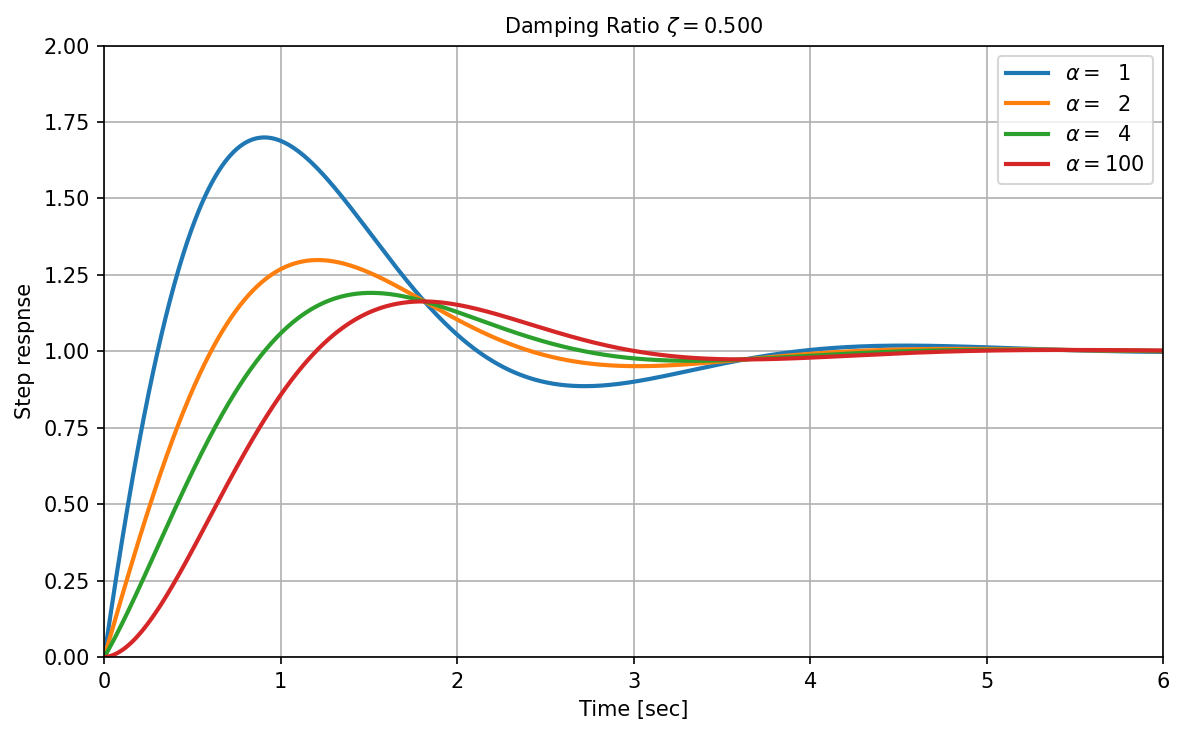

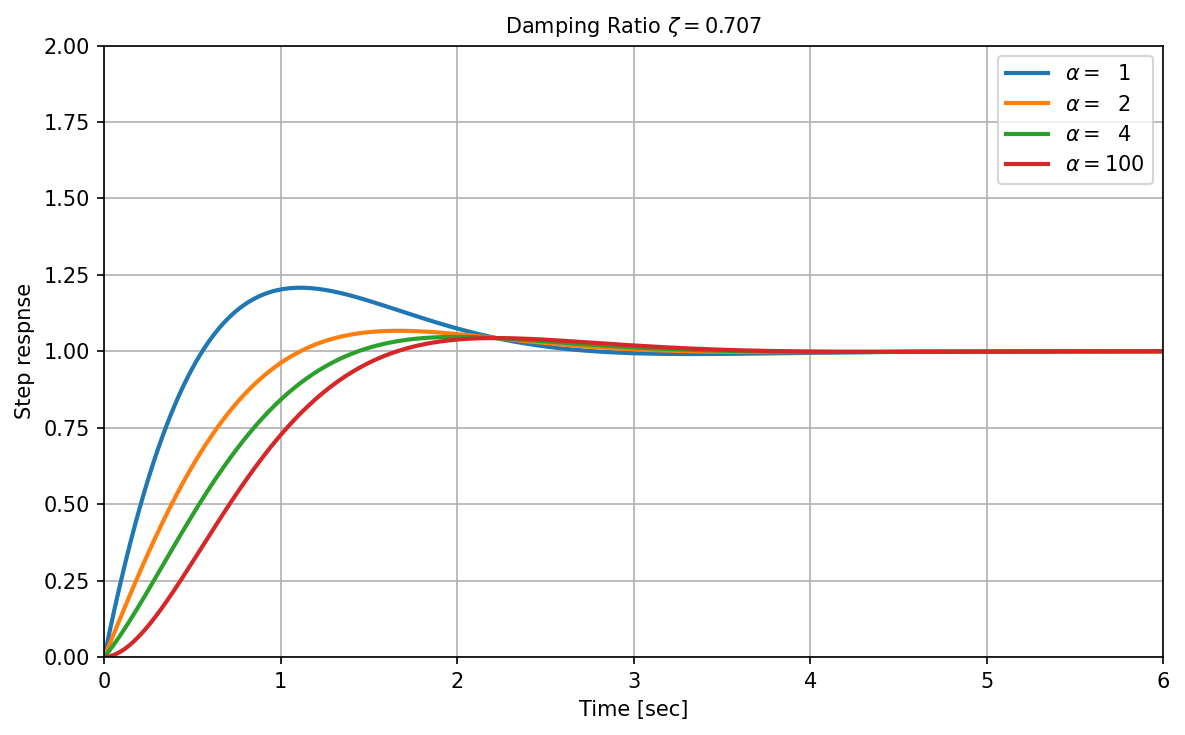

In [17]:
wn = 2
tt = np.linspace(0,6,1000)

for zeta in np.array([0.5, 1/np.sqrt(2)]):
    wd = wn * np.sqrt(1-zeta**2)
    fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,sharex = True)
    for alpha in np.array([1,2,4,100]):
        coef = (alpha*zeta**2 - 1)/alpha/zeta/np.sqrt(1-zeta**2)
        y = 1 - np.exp(-zeta*wn*tt)*(np.cos(wd * tt) + np.sin(wd *tt) * coef)
        plt.plot(tt,y,label=r'$\alpha=${:3.0f}'.format(alpha))
    plt.title("Damping Ratio $\zeta=${:4.3f}".format(zeta))
    plt.legend()
    plt.xlabel("Time [sec]")
    plt.ylabel("Step respnse")
    plt.ylim(0,2)
    savefig("./figs/Zeros_Ex_"+str(round(zeta,3))+".pdf", dpi=600)
    plt.show()

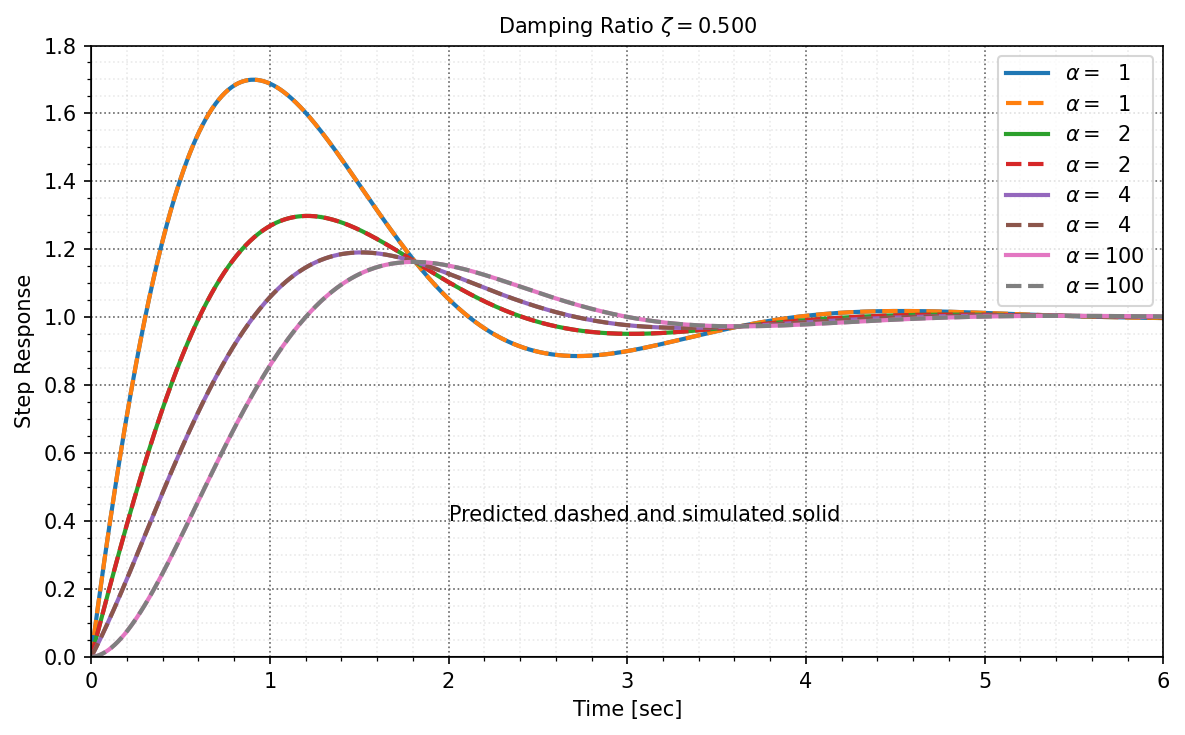

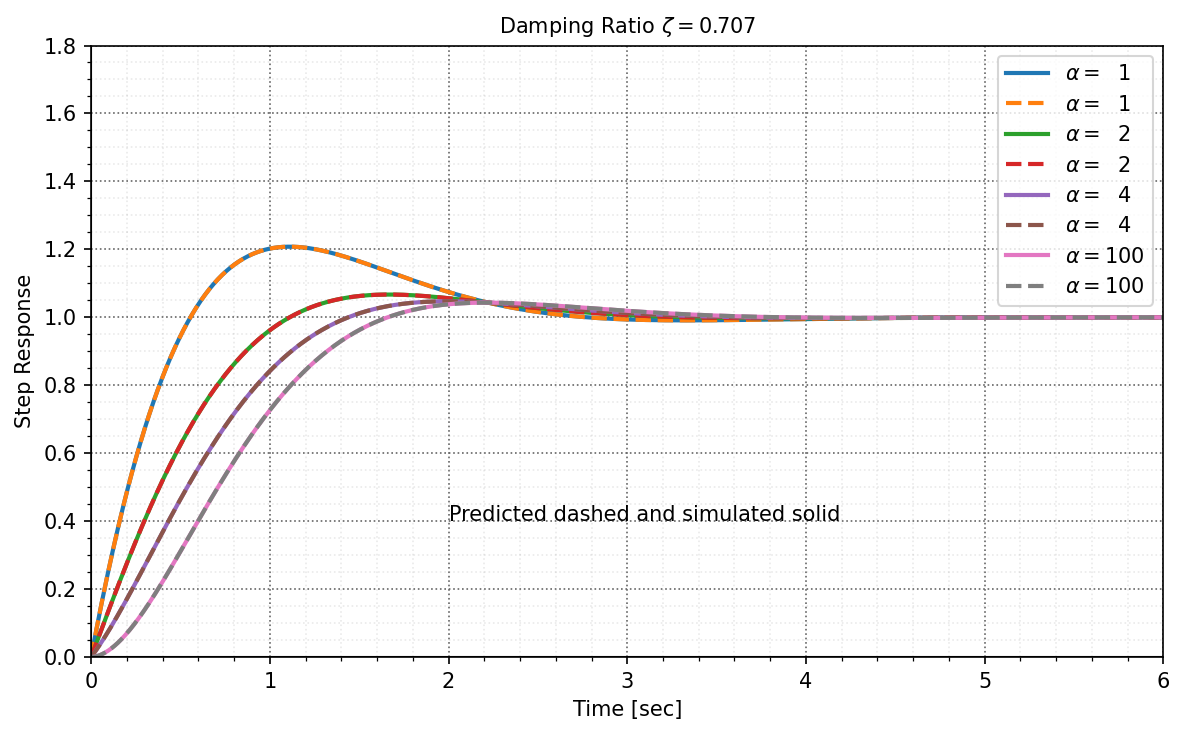

In [18]:
# Lecture 6-20
wn = 2

tt = np.linspace(0,6,1000)
for zeta in np.array([0.5, 1/np.sqrt(2)]):
    fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,sharex = True)
    plt.title("Damping Ratio $\zeta=${:4.3f}".format(zeta))
    plt.xlabel("Time [sec]")
    plt.ylabel("Step Response")
    wd = wn * np.sqrt(1-zeta**2)
    for alp in np.array([1,2,4,100]):
        G = tf((wn/(alp*zeta), wn**2), (1, 2*zeta*wn, wn**2))
        [yy,tt] = step(G,tt)
        plt.plot(tt,yy,label=r'$\alpha=${:3.0f}'.format(alp))

        coef = (alp*zeta**2 - 1)/(alp * zeta *np.sqrt(1-zeta**2))
        y = 1 - np.exp(-zeta*wn*tt)*(np.cos(wd * tt) + coef * np.sin(wd * tt))
        plt.plot(tt,y,'--',label=r'$\alpha=${:3.0f}'.format(alp))
    plt.legend()
    plt.text(2,.4,'Predicted dashed and simulated solid')
    plt.ylim((0,1.8))
    nicegrid()
    savefig("./figs/Zeros_Ex_"+str(round(zeta,3))+".pdf", dpi=600)
    plt.show()

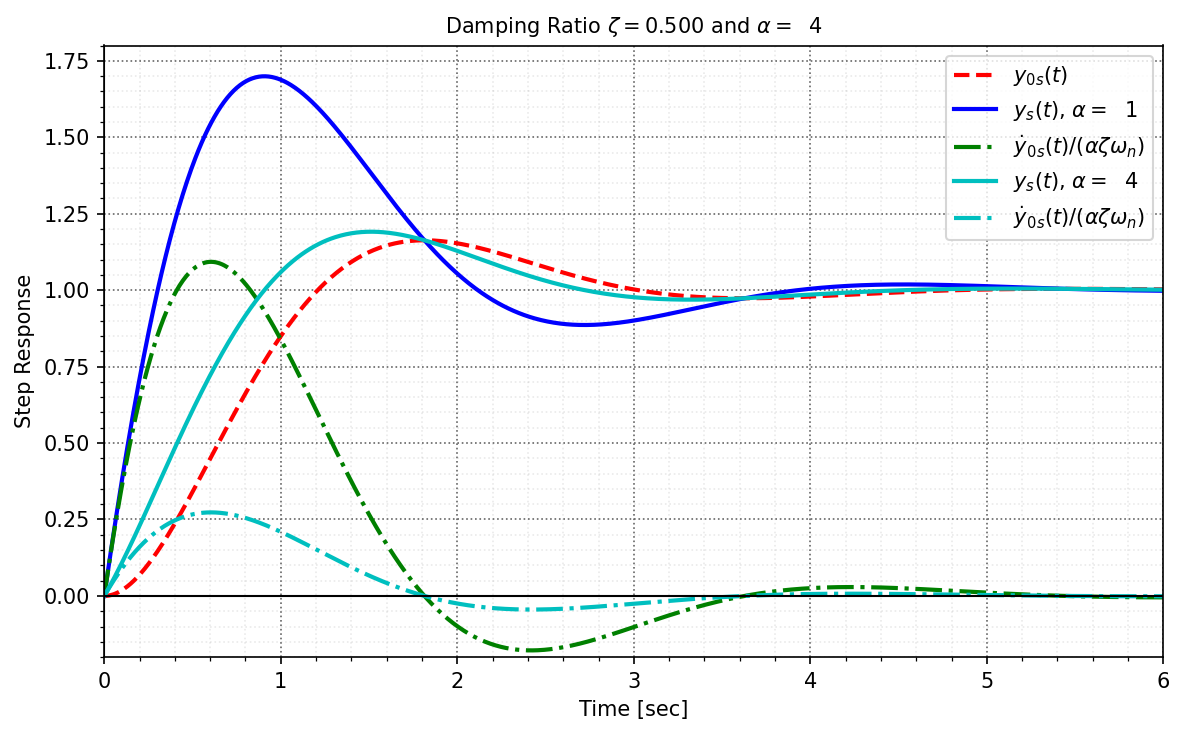

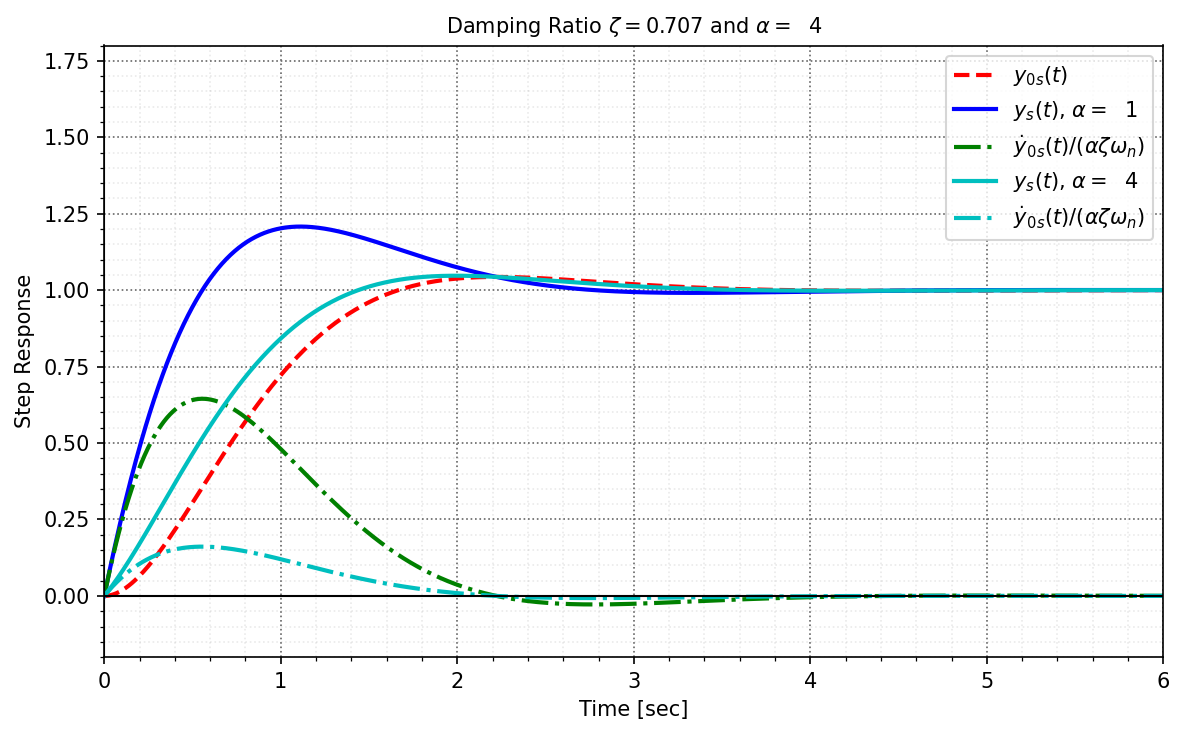

In [19]:
# Lecture 6-20
wn = 2
tt = np.linspace(0,6,1000)
for zeta in np.array([0.5, 1/np.sqrt(2)]):
    fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,sharex = True)
    plt.xlabel("Time [sec]")
    plt.ylabel("Step Response")
    for alp in np.array([1,4]):
        G = tf((wn/(alp*zeta), wn**2), (1, 2*zeta*wn, wn**2))
        G0 = tf((0, wn**2), (1, 2*zeta*wn, wn**2))
        G0d = tf((wn**2/(alp*zeta*wn), 0), (1, 2*zeta*wn, wn**2))
        [yy,tt] = step(G,tt)
        [yy0,tt] = step(G0,tt)
        [yy0d,tt] = step(G0d,tt)
        if alp < 4:
            plt.plot(tt,yy0,'r--',label=r'$y_{0s}(t)$')
            plt.plot(tt,yy,'b',label=r'$y_s(t)$, $\alpha=${:3.0f}'.format(alp))
            plt.plot(tt,yy0d,'g-.',label=r'$\dot y_{0s}(t)/(\alpha\zeta\omega_n)$')
        else:
            plt.plot(tt,yy,'c',label=r'$y_s(t)$, $\alpha=${:3.0f}'.format(alp))
            plt.plot(tt,yy0d,'c-.',label=r'$\dot y_{0s}(t)/(\alpha\zeta\omega_n)$')
        plt.title(r"Damping Ratio $\zeta=${:4.3f} and $\alpha=${:3.0f}".format(zeta,alp))
    plt.legend()
    nicegrid()
    plt.ylim((-0.2,1.8))
    savefig("./figs/Zeros_Ex2_"+str(round(zeta,3))+".pdf", dpi=600)
    plt.show()

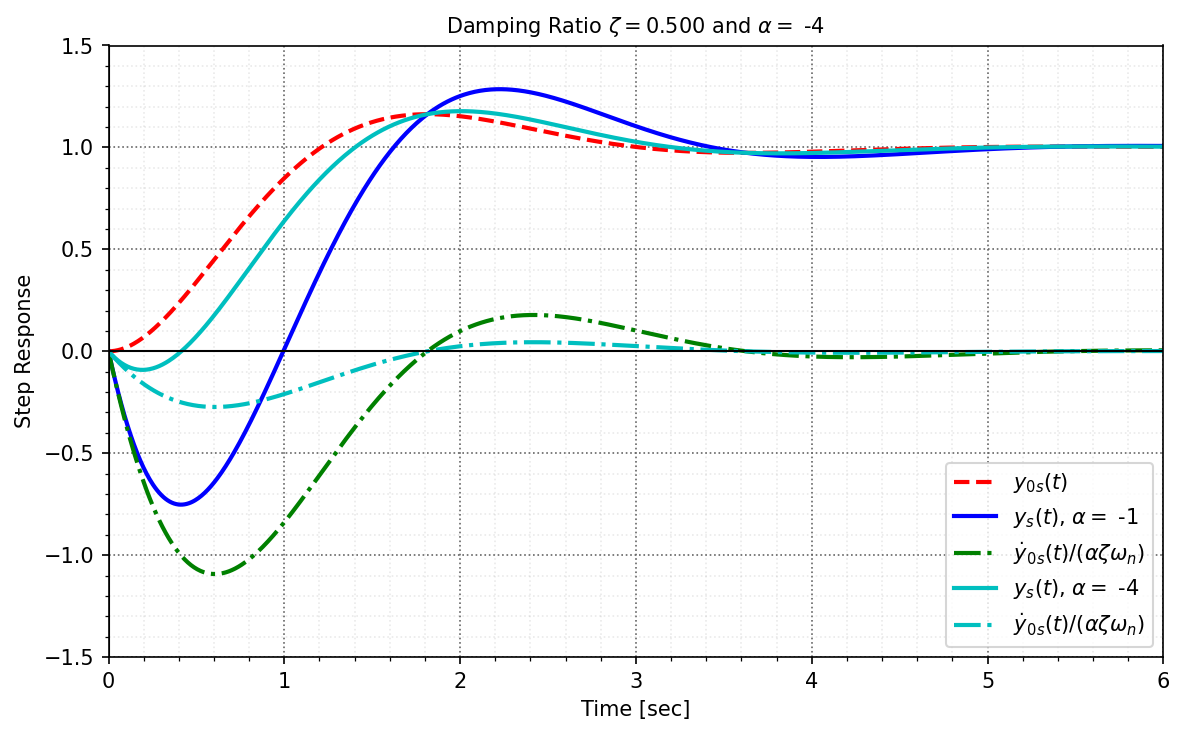

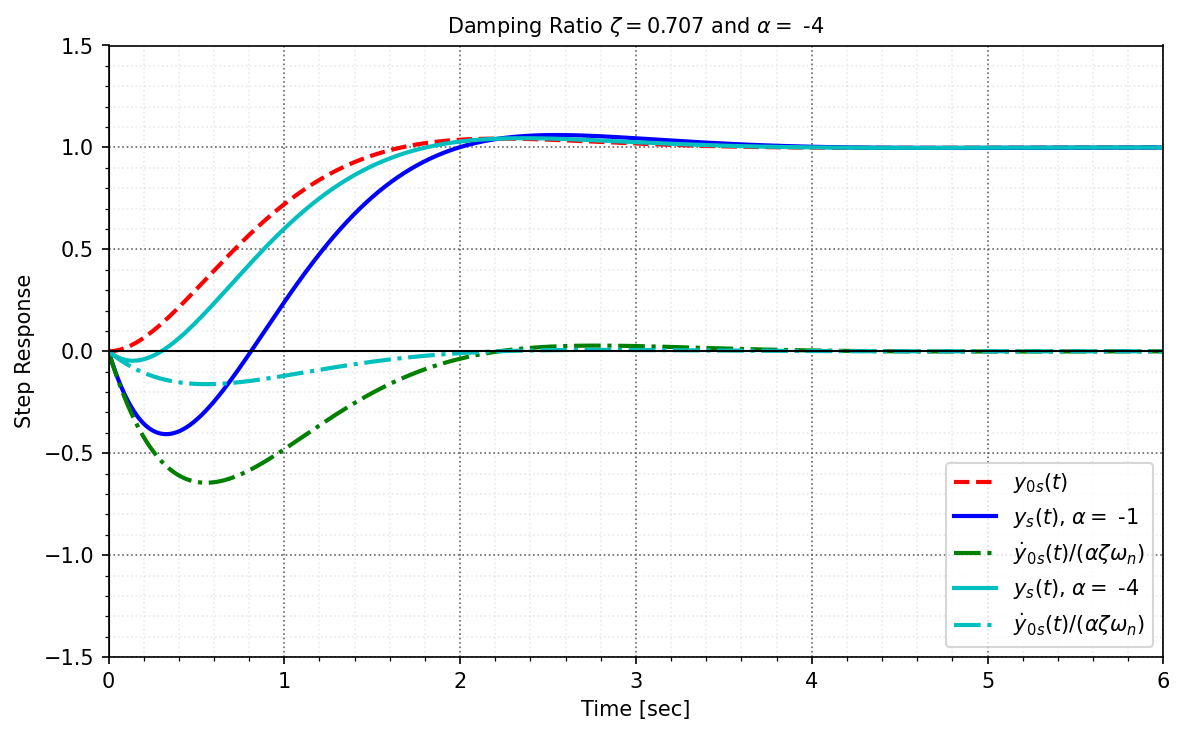

In [20]:
# Lecture 6-20
wn = 2
tt = np.linspace(0,6,1000)
for zeta in np.array([0.5, 1/np.sqrt(2)]):
    fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,sharex = True)
    plt.xlabel("Time [sec]")
    plt.ylabel("Step Response")
    for alp in np.array([-1,-4]):
        G = tf((wn/(alp*zeta), wn**2), (1, 2*zeta*wn, wn**2))
        G0 = tf((0, wn**2), (1, 2*zeta*wn, wn**2))
        G0d = tf((wn**2/(alp*zeta*wn), 0), (1, 2*zeta*wn, wn**2))
        [yy,tt] = step(G,tt)
        [yy0,tt] = step(G0,tt)
        [yy0d,tt] = step(G0d,tt)
        if alp > -4:
            plt.plot(tt,yy0,'r--',label=r'$y_{0s}(t)$')
            plt.plot(tt,yy,'b',label=r'$y_s(t)$, $\alpha=${:3.0f}'.format(alp))
            plt.plot(tt,yy0d,'g-.',label=r'$\dot y_{0s}(t)/(\alpha\zeta\omega_n)$')
        else:
            plt.plot(tt,yy,'c',label=r'$y_s(t)$, $\alpha=${:3.0f}'.format(alp))
            plt.plot(tt,yy0d,'c-.',label=r'$\dot y_{0s}(t)/(\alpha\zeta\omega_n)$')
        plt.title(r"Damping Ratio $\zeta=${:4.3f} and $\alpha=${:3.0f}".format(zeta,alp))
    plt.legend()
    nicegrid()
    plt.ylim((-1.5,1.5))
    savefig("./figs/Zeros_Ex3_"+str(round(zeta,3))+".pdf", dpi=600)
    plt.show()

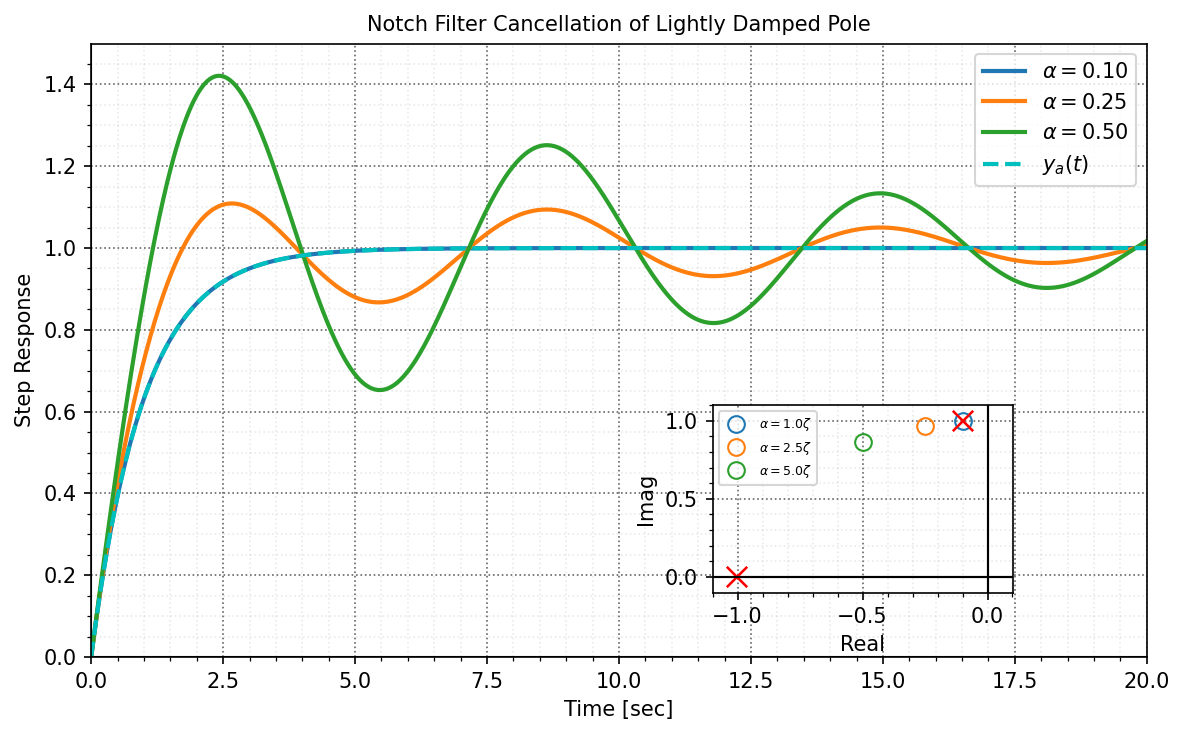

In [21]:
# Lecture 6-22
zeta = 0.1
wn = 1
tt = np.linspace(0,20,1000)
fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,sharex = True)
ax.set_xlabel("Time [sec]")
ax.set_ylabel("Step Response")
nicegrid(ax)

left, bottom, width, height = [0.6, 0.2, 0.25, 0.25]
ax2 = fig.add_axes([left, bottom, width, height])
ax2.figure.set_facecolor('w')
nicegrid(ax2)
ax2.set_xlabel("Real")
ax2.set_ylabel("Imag")

for alp in np.array([0.1, 0.25, 0.5]):
    G = tf((1, 2*alp*wn, wn**2), np.convolve((1, 2*zeta*wn, wn**2),(1,1)))
    [yy,tt] = step(G,tt)
    ax.plot(tt,yy,label=r'$\alpha={:3.2f}$'.format(alp))

    ax2.plot(np.real(G.poles()),np.imag(G.poles()), 'x', ms=10, color='red')
    ax2.plot(np.real(G.zeros()),np.imag(G.zeros()), 'o', markerfacecolor='none', ms=8, label=r'$\alpha={:2.1f}\zeta$'.format(alp/zeta))
    
Ga = tf((1), (1,1))
[yya,tt] = step(Ga,tt)
ax.plot(tt,yya,'c--',label=r'$y_a(t)$')
ax.set_title(r"Notch Filter Cancellation of Lightly Damped Pole")
ax.legend()
ax2.legend(prop = { "size": 6 })
ax.set_ylim((0,1.5))
ax2.set_xlim((-1.1,0.1))
ax2.set_ylim((-0.1,1.1))
nicegrid()
savefig("./figs/Zeros_Ex4_"+str(round(zeta,3))+".pdf", dpi=600)
plt.show()

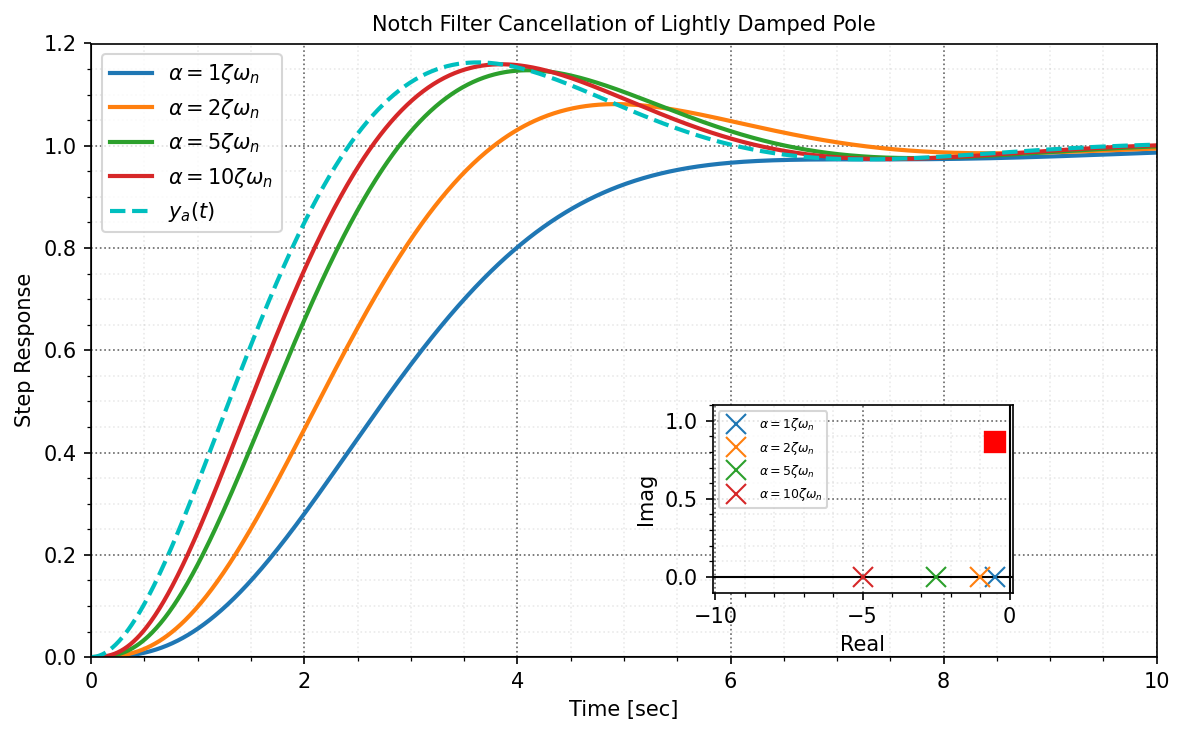

In [22]:
# Lecture 6-22
# Add pole

zeta = 0.5
wn = 1
tt = np.linspace(0,10,1000)
fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,sharex = True)
ax.set_xlabel("Time [sec]")
ax.set_ylabel("Step Response")
nicegrid(ax)

left, bottom, width, height = [0.6, 0.2, 0.25, 0.25]
ax2 = fig.add_axes([left, bottom, width, height])
ax2.figure.set_facecolor('w')
nicegrid(ax2)
ax2.set_xlabel("Real")
ax2.set_ylabel("Imag")

Ga = tf((wn**2), (1, 2*zeta*wn, wn**2))
for alp in np.array([1,2,5,10]):
    Gp = tf(1, (1/(alp*zeta*wn),1))
    G = Ga*Gp
    [yy,tt] = step(G,tt)
    ax.plot(tt,yy,label=r'$\alpha={:3.0f}\zeta\omega_n$'.format(alp))

    ax2.plot(np.real(Ga.poles()),np.imag(Ga.poles()), 'rs', ms=10)
    ax2.plot(np.real(Gp.poles()),np.imag(Gp.poles()), 'x', ms=10, label=r'$\alpha={:2.0f}\zeta\omega_n$'.format(alp))
    
[yya,tt] = step(Ga,tt)
ax.plot(tt,yya,'c--',label=r'$y_a(t)$')
ax.set_title(r"Notch Filter Cancellation of Lightly Damped Pole")
ax.legend()
ax2.legend(prop = { "size": 6 })
ax.set_ylim((0,1.2))
ax2.set_xlim((-10.1,0.1))
ax2.set_ylim((-0.1,1.1))
savefig("./figs/Zeros_Ex5_"+str(round(zeta,3))+".pdf", dpi=600)
plt.show()

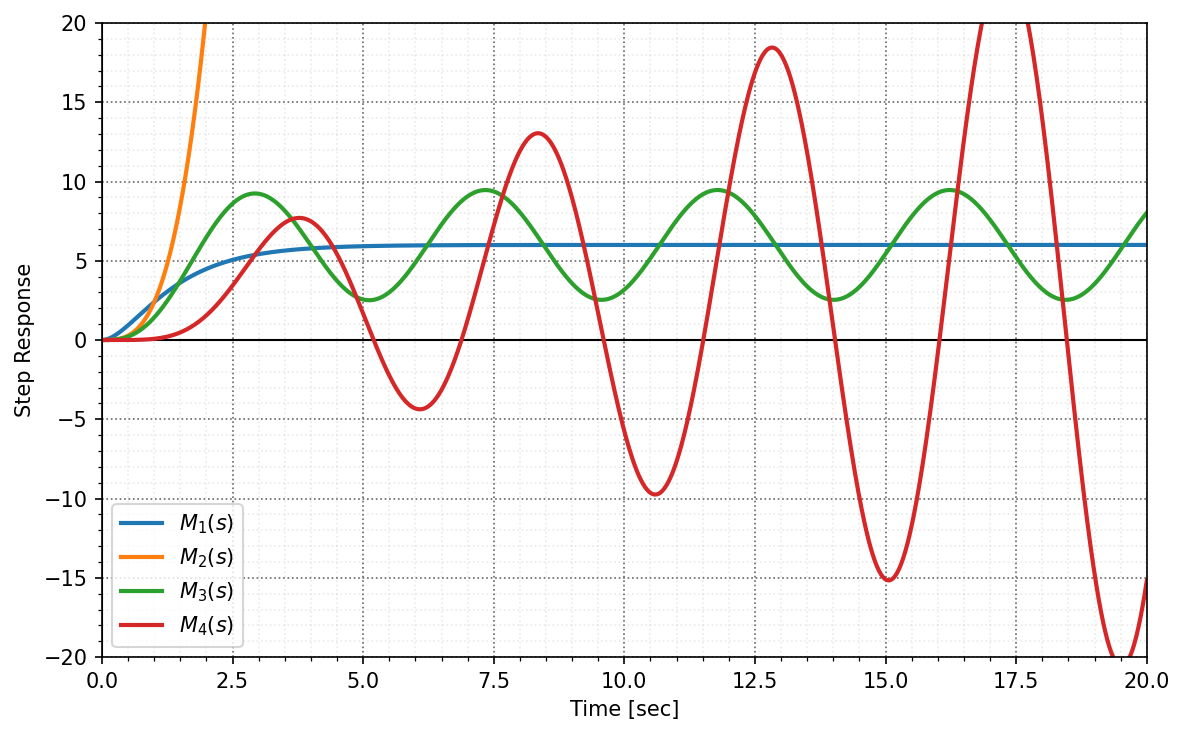

In [23]:
# Lecture 8-4
# Add pole

zeta = 0.5
wn = 1
tt = np.linspace(0,20,1000)
fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,sharex = True)
ax.set_xlabel("Time [sec]")
ax.set_ylabel("Step Response")
nicegrid(ax)

T0 = tf((1), (1,1))
T1 = tf((1), (1,2))
T2 = tf((1), (1,0,2))
T3 = tf((1), (1,-1))
G0 = 12*T1*T0
G1 = 12*T3*T2
G2 = 12*T0*T2
G3 = 12*T0*T2**2

[yy0,tt] = step(G0,tt)
[yy1,tt] = step(G1,tt)
[yy2,tt] = step(G2,tt)
[yy3,tt] = step(G3,tt)

ax.plot(tt,yy0,label=r'$M_1(s)$')
ax.plot(tt,yy1,label=r'$M_2(s)$')
ax.plot(tt,yy2,label=r'$M_3(s)$')
ax.plot(tt,yy3,label=r'$M_4(s)$')
ax.legend()
ax.set_ylim((-20,20))
savefig("./figs/Ex84.pdf", dpi=600)
plt.show()